### Install Library

In [1]:
!pip install transformers datasets scikit-learn accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 17.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
import pandas as pd
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
import torch

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Use device: {device}")

Use device: cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Read data

In [5]:
print("Sedang mendownload data mentah dari GitHub IndoNLU...")

try:
    # URL File Mentah (TSV) dari repository resmi IndoBenchmark
    train_url = "https://raw.githubusercontent.com/indobenchmark/indonlu/master/dataset/smsa_doc-sentiment-prosa/train_preprocess.tsv"
    valid_url = "https://raw.githubusercontent.com/indobenchmark/indonlu/master/dataset/smsa_doc-sentiment-prosa/valid_preprocess.tsv"

    # read pd
    df_train = pd.read_csv(train_url, sep='\t', names=['text', 'label'])
    df_valid = pd.read_csv(valid_url, sep='\t', names=['text', 'label'])

    print(f"Berhasil download! Total data train: {len(df_train)}, valid: {len(df_valid)}")

    # Mapping Label Text ke Angka
    label_map = {'positive': 0, 'neutral': 1, 'negative': 2}

    df_train['label'] = df_train['label'].map(label_map)
    df_valid['label'] = df_valid['label'].map(label_map)

    # Konversi ke format Hugging Face Dataset
    train_dataset_hf = Dataset.from_pandas(df_train)
    eval_dataset_hf = Dataset.from_pandas(df_valid)

except Exception as e:
    print(f"download data error: {e}")

Sedang mendownload data mentah dari GitHub IndoNLU...
Berhasil download! Total data train: 11000, valid: 1260


###Preprocessing

In [6]:
model_name = "w11wo/indonesian-roberta-base-sentiment-classifier"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Konfigurasi Label Model
id2label = {0: "positive", 1: "neutral", 2: "negative"}
label2id = {"positive": 0, "neutral": 1, "negative": 2}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
).to(device)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

train_dataset_tokenized = train_dataset_hf.map(tokenize_function, batched=True)
eval_dataset_tokenized = eval_dataset_hf.map(tokenize_function, batched=True)

train_dataset_final = train_dataset_tokenized.shuffle(seed=42).select(range(500))
eval_dataset_final = eval_dataset_tokenized.shuffle(seed=42).select(range(100))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Map:   0%|          | 0/11000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1260 [00:00<?, ? examples/s]

###Matrics evaluation

In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    acc = accuracy_score(labels, predictions)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

###Training

In [8]:
training_args = TrainingArguments(
    output_dir="./hasil_training_smsa",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_final,
    eval_dataset=eval_dataset_final,
    compute_metrics=compute_metrics,
)



###Main execute

In [9]:
print("\n=== Start FINE-TUNING ===")
trainer.train()

####################################
print("\n" + "="*50)
print("MODEL EVALUATION RESULT ")
print("="*50)
final_metrics = trainer.evaluate()

print(f"Dataset           : IndoBenchmark (SmSA) via GitHub")
print(f"Accuracy Model    : {final_metrics['eval_accuracy']:.2%}")
print(f"Precision         : {final_metrics['eval_precision']:.4f}")
print(f"Recall            : {final_metrics['eval_recall']:.4f}")
print(f"F1-Score          : {final_metrics['eval_f1']:.4f}")
print("="*50)

# Save model
path_model = "/content/drive/MyDrive/BigProject_SentimentYT/hasil-trainingSmSA"
trainer.save_model(path_model)
print(f"Model saved:'{path_model}'")


=== Start FINE-TUNING ===


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.131014,0.980000,0.980161,0.981000,0.980000
2,No log,0.154906,0.960000,0.961612,0.967346,0.960000
3,No log,0.151279,0.970000,0.970149,0.970846,0.970000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


MODEL EVALUATION RESULT 


Dataset           : IndoBenchmark (SmSA) via GitHub
Accuracy Model    : 98.00%
Precision         : 0.9810
Recall            : 0.9800
F1-Score          : 0.9802


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved:'/content/drive/MyDrive/BigProject_SentimentYT/hasil-trainingSmSA'


In [10]:
import shutil
shutil.make_archive('model_sentiment', 'zip', '/content/drive/MyDrive/BigProject_SentimentYT/hasil-trainingSmSA')
print("DOWNLOAD DONE")

DOWNLOAD DONE


### EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1260 non-null   object
 1   label   1260 non-null   object
dtypes: object(2)
memory usage: 19.8+ KB

=== Top 5 Data ===


,text,label
0,"meski masa kampanye sudah selesai , bukan bera...",neutral
1,tidak enak,negative
2,restoran ini menawarkan makanan sunda . kami m...,positive
3,lokasi di alun alun masakan padang ini cukup t...,positive
4,betapa bejad kader gerindra yang anggota dprd ...,negative



=== Statistic sentiment ===
label
positive    735
negative    394
neutral     131
Name: count, dtype: int64


/tmp/ipython-input-1047306980.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette='viridis', order=sentiment_counts.index)


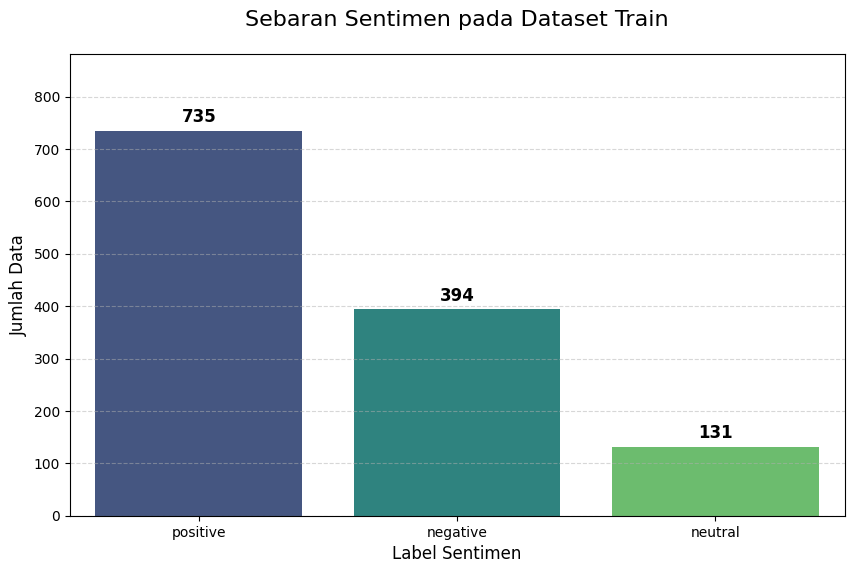

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "/content/drive/MyDrive/PemrosesanTeks_Praktik/BigProject_SentimentYT/Dataset/train_preprocess.tsv"

try:
    df = pd.read_csv(file_path, sep='\t', names=['text', 'label'])

    # info
    df.info()

    # Tampilkan 5 data teratas
    print("\n=== Top 5 Data ===")
    display(df.head())

    # Menghitung Jumlah Sebaran Data
    sentiment_counts = df['label'].value_counts()

    print("\n=== Statistic sentiment ===")
    print(sentiment_counts)

    # Visualisasi Grafik Batang
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(x='label', data=df, palette='viridis', order=sentiment_counts.index)

    plt.title('Sebaran Sentimen pada Dataset Train', fontsize=16, pad=20)
    plt.xlabel('Label Sentimen', fontsize=12)
    plt.ylabel('Jumlah Data', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # cari nilai tertinggi (max count) untuk mengatur tinggi grafik
    max_height = sentiment_counts.max()

    # batas atas grafik
    plt.ylim(0, max_height * 1.2)

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center',
                   va = 'center',
                   xytext = (0, 10),
                   textcoords = 'offset points',
                   fontsize=12,
                   fontweight='bold')

    plt.show()

except FileNotFoundError:
    print(f"Error: File tidak ditemukan di path: {file_path}")
    print("Pastikan Google Drive sudah di-mount dan path filenya benar.")
except Exception as e:
    print(f"Terjadi kesalahan: {e}")

Sedang membaca dataset...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    500 non-null    object
 1   label   500 non-null    object
dtypes: object(2)
memory usage: 7.9+ KB

=== Top 5 Data ===


,text,label
0,kemarin gue datang ke tempat makan baru yang a...,negative
1,kayak nya sih gue tidak akan mau balik lagi ke...,negative
2,"kalau dipikir-pikir , sebenarnya tidak ada yan...",negative
3,ini pertama kalinya gua ke bank buat ngurusin ...,negative
4,waktu sampai dengan gue pernah disuruh ibu lat...,negative



=== Statistic sentiment ===
label
positive    208
negative    204
neutral      88
Name: count, dtype: int64


/tmp/ipython-input-2215337660.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette='viridis', order=sentiment_counts.index)


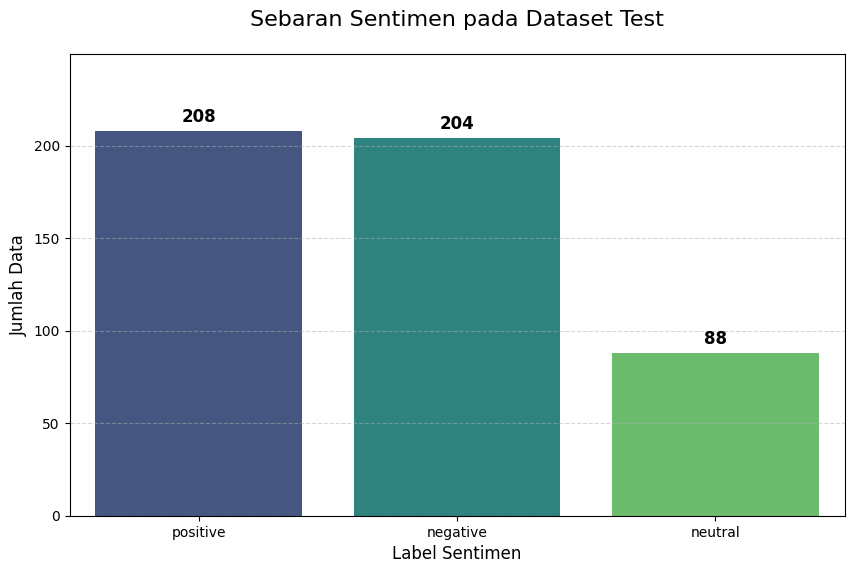

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "/content/drive/MyDrive/PemrosesanTeks_Praktik/BigProject_SentimentYT/Dataset/test_preprocess.tsv"

try:
    print("Sedang membaca dataset...")
    df = pd.read_csv(file_path, sep='\t', names=['text', 'label'])

    # info
    df.info()

    # Tampilkan 5 data teratas
    print("\n=== Top 5 Data ===")
    display(df.head())

    # Menghitung Jumlah Sebaran Data
    sentiment_counts = df['label'].value_counts()

    print("\n=== Statistic sentiment ===")
    print(sentiment_counts)

    # 4. Visualisasi Grafik Batang
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(x='label', data=df, palette='viridis', order=sentiment_counts.index)

    plt.title('Sebaran Sentimen pada Dataset Test', fontsize=16, pad=20)
    plt.xlabel('Label Sentimen', fontsize=12)
    plt.ylabel('Jumlah Data', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    max_height = sentiment_counts.max()

    plt.ylim(0, max_height * 1.2)


    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center',
                   va = 'center',
                   xytext = (0, 10),
                   textcoords = 'offset points',
                   fontsize=12,
                   fontweight='bold')

    plt.show()

except FileNotFoundError:
    print(f"Error: File tidak ditemukan di path: {file_path}")
    print("Pastikan Google Drive sudah di-mount dan path filenya benar.")
except Exception as e:
    print(f"Terjadi kesalahan: {e}")